Initializing localized classification training dataset...

--- Training Samples Ingestion Preview ---
   metric_a  metric_b  metric_c  metric_d  target
0  0.496714 -0.138264  0.647689  1.523030       0
1 -0.234153 -0.234137  1.579213  0.767435       0
2 -0.469474  0.542560 -0.463418 -0.465730       0
3  0.241962 -1.913280 -1.724918 -0.562288       0
4 -1.012831  0.314247 -0.908024 -1.412304       0

Training Predictive Random Forest Classifier Strategy...

--- Raw Confusion Matrix Metrics Output ---
[[55  1]
 [ 1 43]]

--- Structured Classification Report Metrics ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        56
           1       0.98      0.98      0.98        44

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100

Calculated Area Under the Curve (AUC): 0.9992


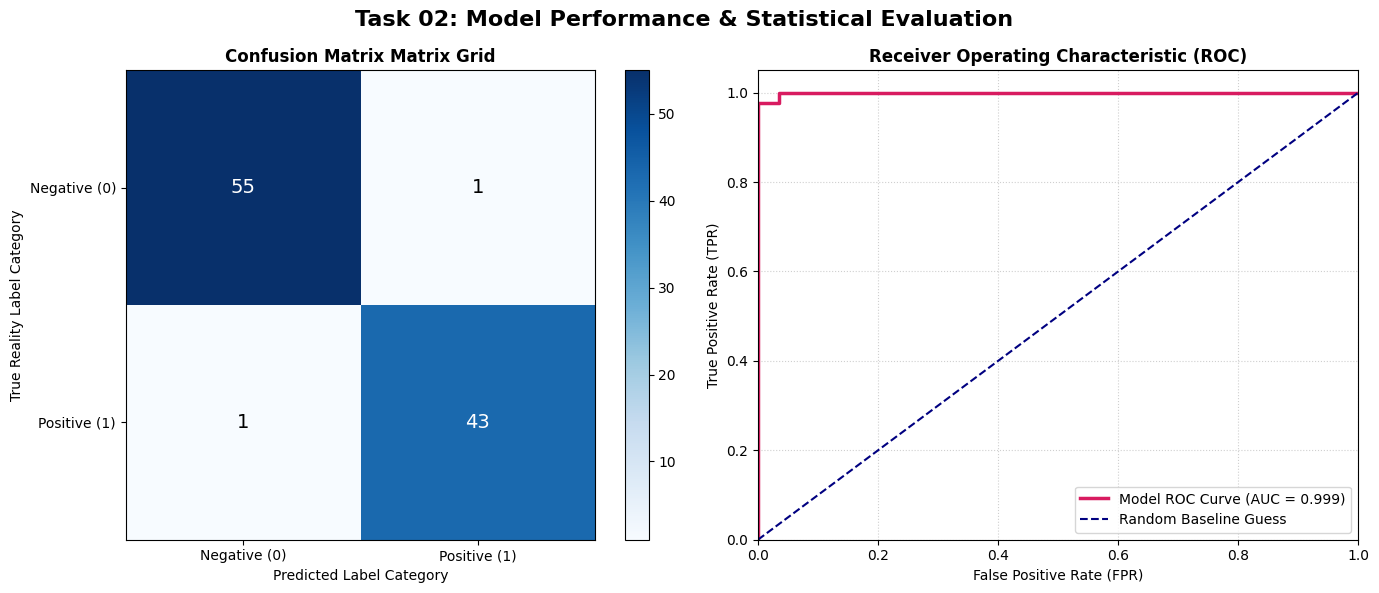

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# ==========================================
# PART 1: DATASET INGESTION & TRAINING
# ==========================================
print("Initializing localized classification training dataset...")

# Creating an algorithmic synthetic dataset representing historical metrics
np.random.seed(42)
X_features = np.random.randn(500, 4)  # 4 variance parameter weights
# Mapping predictive ground truths with logic bounds
y_targets = (X_features[:, 0] + X_features[:, 1] * 1.5 > 0.5).astype(int)

# Structural conversion
df = pd.DataFrame(X_features, columns=['metric_a', 'metric_b', 'metric_c', 'metric_d'])
df['target'] = y_targets

print("\n--- Training Samples Ingestion Preview ---")
print(df.head())

# Split into structured validation parameters (80% Train, 20% Evaluation Test)
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Fit a Random Forest Classifier strategy onto your validation records
print("\nTraining Predictive Random Forest Classifier Strategy...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


# ==========================================
# PART 2: MACHINE LEARNING EVALUATION METRICS
# ==========================================

# 1. Generate core predictive outcomes
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]  # Extracted array for ROC curves

# 2. Extract Confusion Matrix metrics
cm = confusion_matrix(y_test, y_pred)
print("\n--- Raw Confusion Matrix Metrics Output ---")
print(cm)

# 3. Print Comprehensive Performance Metrics [05:22]
print("\n--- Structured Classification Report Metrics ---")
print(classification_report(y_test, y_pred))

# 4. Process ROC Boundary Line Coordinates & Compute AUC [01:47, 04:07]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
print(f"Calculated Area Under the Curve (AUC): {roc_auc:.4f}")


# ==========================================
# PART 3: REPOSITORY EVALUATION DASHBOARD
# ==========================================

# Setup double subplot framework to showcase evaluation benchmarks
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Task 02: Model Performance & Statistical Evaluation', fontsize=16, fontweight='bold')

# Plot A: Confusion Matrix Heatmap Representation [01:03]
ax_cm = axes[0]
im = ax_cm.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax_cm.figure.colorbar(im, ax=ax_cm)

# Configure matrix boundary tick labels
classes = ['Negative (0)', 'Positive (1)']
tick_marks = np.arange(len(classes))
ax_cm.set_xticks(tick_marks)
ax_cm.set_yticks(tick_marks)
ax_cm.set_xticklabels(classes)
ax_cm.set_yticklabels(classes)

# Annotate values inside the confusion grid spaces [04:17]
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax_cm.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black", fontsize=14)

ax_cm.set_title('Confusion Matrix Matrix Grid', fontsize=12, fontweight='bold')
ax_cm.set_xlabel('Predicted Label Category')
ax_cm.set_ylabel('True Reality Label Category')

# Plot B: Receiver Operating Characteristic (ROC Line Graph) [01:03, 01:47]
ax_roc = axes[1]
ax_roc.plot(fpr, tpr, color='#D81B60', lw=2.5, label=f'Model ROC Curve (AUC = {roc_auc:.3f})')
ax_roc.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Baseline Guess') # Diagonal line [01:03]

ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate (FPR)')
ax_roc.set_ylabel('True Positive Rate (TPR)')
ax_roc.set_title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
ax_roc.legend(loc="lower right")
ax_roc.grid(True, linestyle=':', alpha=0.6)

# Display completed assignment validation metrics
plt.tight_layout()
plt.show()